<a href="https://colab.research.google.com/github/2403a54127-lab/FUTURE_DS_01_TASK1/blob/main/FUTURE_DS_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 7)

Missing Values
Order_ID    0
Date        0
Region      0
Category    0
Product     0
Sales       0
Quantity    0
dtype: int64

Total Sales : 17162569
Total Profit : Data Missing (column 'Profit')
Average Discount : Data Missing (column 'Discount')
Total Orders : 1000


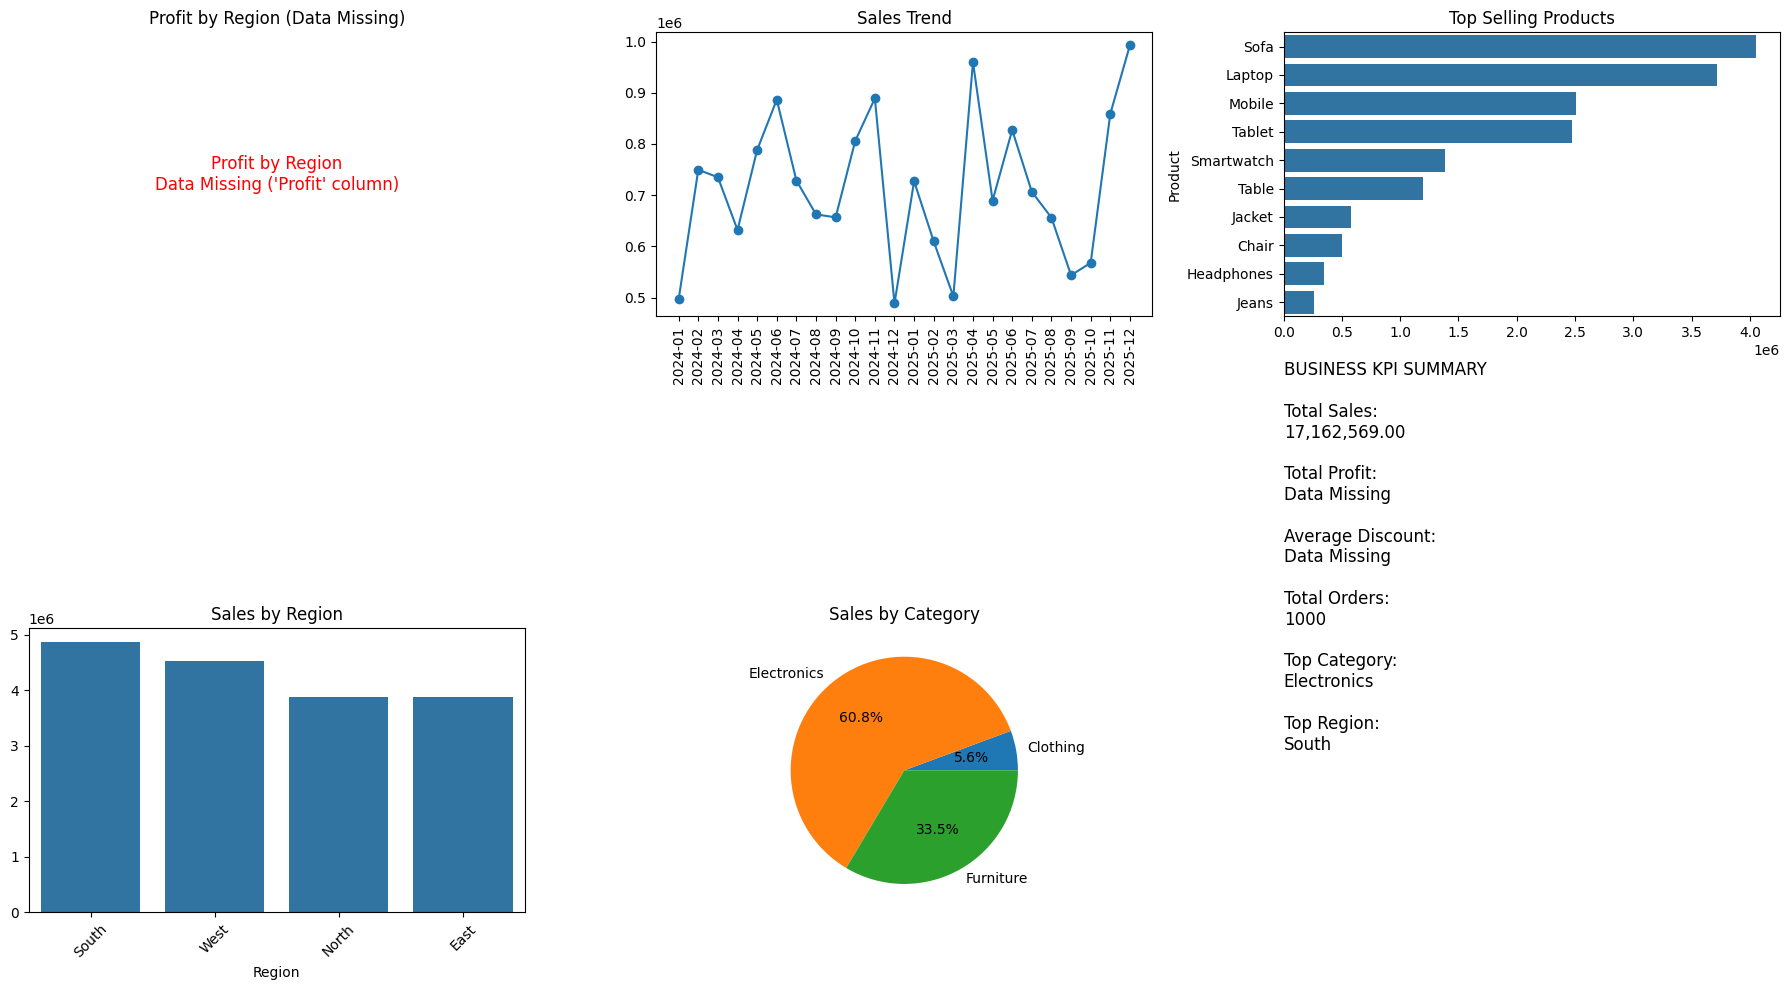


========== KEY INSIGHTS ==========
Top Region: South
Top Category: Electronics
Top Product: Sofa
Highest Profit Region: Data Missing ('Profit' column)

========== RECOMMENDATIONS ==========
1. Increase inventory for top products.
2. Focus marketing on best-performing categories.
3. Improve sales in low-performing regions.
4. Optimize discount strategy.
5. Use monthly trends for demand forecasting.


In [4]:
# ==========================
# Business Sales Analytics
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# Load Dataset
# --------------------------

df = pd.read_csv("sales_data_1000_rows.csv")

# --------------------------
# Data Cleaning
# --------------------------

print("Dataset Shape:", df.shape)

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

print("\nMissing Values")
print(df.isnull().sum())

# --------------------------
# KPI Calculations
# --------------------------

total_sales = df['Sales'].sum()
total_profit = 0 # 'Profit' column is missing
avg_discount = 0 # 'Discount' column is missing
total_orders = df.shape[0]

print("\nTotal Sales :", round(total_sales,2))
print("Total Profit : Data Missing (column 'Profit')")
print("Average Discount : Data Missing (column 'Discount')")
print("Total Orders :", total_orders)

# --------------------------
# Sales by Region
# --------------------------

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# --------------------------
# Profit by Region
# --------------------------

region_profit = pd.Series(dtype='float64') # Placeholder as 'Profit' column is missing

# --------------------------
# Sales by Category
# --------------------------

category_sales = df.groupby('Category')['Sales'].sum()

# --------------------------
# Top Products
# --------------------------

top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# --------------------------
# Monthly Sales Trend
# --------------------------

monthly_sales = (
    df.groupby(df['Date'].dt.to_period('M'))['Sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

# --------------------------
# Dashboard Creation
# --------------------------

plt.figure(figsize=(18,10))

# --------------------------
# Chart 1
# --------------------------

plt.subplot(2,3,1)

plt.text(0.5, 0.5, "Profit by Region\nData Missing ('Profit' column)",
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=12, color='red')
plt.title("Profit by Region (Data Missing)")
plt.xticks([])
plt.yticks([])
plt.box(False)

# --------------------------
# Chart 2
# --------------------------

plt.subplot(2,3,2)

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Sales Trend")
plt.xticks(rotation=90)

# --------------------------
# Chart 3
# --------------------------

plt.subplot(2,3,3)

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Selling Products")

# --------------------------
# Chart 4
# --------------------------

plt.subplot(2,3,4)

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xticks(rotation=45)

# --------------------------
# Chart 5
# --------------------------

plt.subplot(2,3,5)

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title("Sales by Category")

# --------------------------
# KPI Text
# --------------------------

plt.subplot(2,3,6)
plt.axis('off')

kpi_text = f"""
BUSINESS KPI SUMMARY

Total Sales:
{total_sales:,.2f}

Total Profit:
Data Missing

Average Discount:
Data Missing

Total Orders:
{total_orders}

Top Category:
{category_sales.idxmax()}

Top Region:
{region_sales.idxmax()}
"""

plt.text(
    0,
    0.5,
    kpi_text,
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "Business_Sales_Dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# --------------------------
# Insights
# --------------------------

print("\n========== KEY INSIGHTS ==========")

print(f"Top Region: {region_sales.idxmax()}")

print(f"Top Category: {category_sales.idxmax()}")

print(f"Top Product: {top_products.idxmax()}")

print("Highest Profit Region: Data Missing ('Profit' column)")

print("\n========== RECOMMENDATIONS ==========")

print("1. Increase inventory for top products.")
print("2. Focus marketing on best-performing categories.")
print("3. Improve sales in low-performing regions.")
print("4. Optimize discount strategy.")
print("5. Use monthly trends for demand forecasting.")
